In [2]:
import pandas as pd
import os
import missingno as msno
import matplotlib.pyplot as plt
import re
import seaborn as sns
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

import joblib


# 1. Récupération des données

## 1.1 Récupération de mon path

In [3]:
# Récupération de mon path
data_dir = os.path.dirname('/data/Simplon/cours/tp_ml_voiture/data/2024')
print(data_dir)

/data/Simplon/cours/tp_ml_voiture/data


## 1.2 Boucle pour récupérer automatiquement mes df et les renomer correctement

In [4]:
#Stockage de mes df dans un dict et je fait une boucle pour automatiquement récup mes csv et les mettre en df avec pandas :

dfs = {}
for direc in os.listdir(data_dir) :
    data_path_name = os.path.join(data_dir, direc)
    print(os.listdir(data_path_name))
    
    for file in os.listdir(data_path_name):
        try :
            file_path = os.path.join(data_path_name, file)
            df_name = 'df_' + str(file).replace(".csv", "").replace("-","_")
            dfs[df_name]= pd.read_csv(file_path, sep =";")
            print("------SUCCESS ------")
            print(df_name +":")
            print("--------")
        except Exception as e :
            print(f"AN ERROR HAS OCCURED : {e} in this file : {os.path.basename(file_path)}")
            print("---")            

['caract-2021.csv', 'lieux-2021.csv', 'usagers-2021.csv', '.ipynb_checkpoints']
------SUCCESS ------
df_caract_2021:
--------
------SUCCESS ------
df_lieux_2021:
--------
------SUCCESS ------
df_usagers_2021:
--------
AN ERROR HAS OCCURED : [Errno 21] Is a directory: '/data/Simplon/cours/tp_ml_voiture/data/2021/.ipynb_checkpoints' in this file : .ipynb_checkpoints
---
['caract-2024.csv', 'lieux-2024.csv', 'usagers-2024.csv']
------SUCCESS ------
df_caract_2024:
--------
------SUCCESS ------
df_lieux_2024:
--------
------SUCCESS ------
df_usagers_2024:
--------
['caract-2023.csv', 'lieux-2023.csv', 'usagers-2023.csv']
------SUCCESS ------
df_caract_2023:
--------
------SUCCESS ------
df_lieux_2023:
--------


/tmp/ipykernel_27269/585535203.py:12: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs[df_name]= pd.read_csv(file_path, sep =";")


------SUCCESS ------
df_usagers_2023:
--------
['caract-2022.csv', 'lieux-2022.csv', 'usagers-2022.csv']
------SUCCESS ------
df_caract_2022:
--------
------SUCCESS ------
df_lieux_2022:
--------
------SUCCESS ------
df_usagers_2022:
--------


/tmp/ipykernel_27269/585535203.py:12: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs[df_name]= pd.read_csv(file_path, sep =";")


## 1.3 Renomage de la colonne accident_id par num_acc

In [5]:
dfs["df_caract_2022"].head(1)

,Accident_Id,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
0,202200000001,19,10,2022,16:15,1,26,26198,2,3,1,3,TEIL(vieille route du),"44,5594200000","4,7257200000"


In [6]:
dfs["df_caract_2022"].rename(columns={'Accident_Id': 'Num_Acc'}, inplace=True)

In [7]:
dfs["df_caract_2022"].head(1)

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
0,202200000001,19,10,2022,16:15,1,26,26198,2,3,1,3,TEIL(vieille route du),"44,5594200000","4,7257200000"


## 1.4 Concaténation des dataset par rubrique (lieux, caract, usager)

### 1.4.1 Création d'un colonne année et rennommage pour plus de clarté

In [8]:
# Ajouter une colonne année :
df_groupby_name_list = {}


for name, df in dfs.items() :
    regex_int = re.compile(r'\d+')
    year = regex_int.findall(name)
    numeric_year = int(max(year))
    
    regex_str = re.compile(r'\D+')
    string = regex_str.findall(name)
    new_file_name = string[0]
    print(f"File name without string : {new_file_name}")
    
    print(f"Adding a 'year' column to {name} fill with : {numeric_year}")
    df['year'] = numeric_year

    
    if new_file_name in df_groupby_name_list.keys() :
        df_groupby_name_list[str(new_file_name)].append(df)
        print(f"{name} append to the list : {new_file_name} !")
    else :
        df_groupby_name_list[str(new_file_name)] = [df]
        print(f"List {new_file_name} created & {name} append to it !")
    print("---")
    

print("keys check :")
print(df_groupby_name_list.keys())
    


File name without string : df_caract_
Adding a 'year' column to df_caract_2021 fill with : 2021
List df_caract_ created & df_caract_2021 append to it !
---
File name without string : df_lieux_
Adding a 'year' column to df_lieux_2021 fill with : 2021
List df_lieux_ created & df_lieux_2021 append to it !
---
File name without string : df_usagers_
Adding a 'year' column to df_usagers_2021 fill with : 2021
List df_usagers_ created & df_usagers_2021 append to it !
---
File name without string : df_caract_
Adding a 'year' column to df_caract_2024 fill with : 2024
df_caract_2024 append to the list : df_caract_ !
---
File name without string : df_lieux_
Adding a 'year' column to df_lieux_2024 fill with : 2024
df_lieux_2024 append to the list : df_lieux_ !
---
File name without string : df_usagers_
Adding a 'year' column to df_usagers_2024 fill with : 2024
df_usagers_2024 append to the list : df_usagers_ !
---
File name without string : df_caract_
Adding a 'year' column to df_caract_2023 fill w

### 1.4.2 Concaténiation par année 

In [9]:
concat_dfs = {}

for name, dfs in df_groupby_name_list.items() :
    df_concat_name = re.sub("_$","", name)
    print (df_concat_name)
    
    for df in dfs :
        concat_dfs[df_concat_name] = pd.concat(dfs, ignore_index=True)

df_caract
df_lieux
df_usagers


### 1.4.3 Sortie des dataset de la liste pour une utilisation individuelle plus tard

In [10]:
df_caract = concat_dfs['df_caract']
df_lieux = concat_dfs['df_lieux']
df_usagers = concat_dfs['df_usagers']

***Normalisation des noms de colonnes***

In [11]:
for df in [df_caract, df_lieux, df_usagers]:
    df.columns = (
        df.columns
        .str.lower()
        .str.strip()
        .str.replace(" ", "_")
    )

### 1.4.4 Vérification : ai-je bien toutes les années :

In [12]:
count = df_caract['year'].value_counts()
count

year
2021    56518
2022    55302
2023    54822
2024    54402
Name: count, dtype: int64

# Visualisation & Compréhesnion des données :

## 2.1 Problématique :

#### ***Peut-on prédire la gravité d’un accident corporel (indemne / blessé / tué) à partir des conditions de l’accident, du lieu et du profil de l’usager ?***

### 2.1.2 Variable cible  :

#### ***Colonne "gravité"***

## 2.2 Visualisation des infos etc :

In [13]:
for name, df in concat_dfs.items() :
    print("-"*150)
    print(name," : ")
    print("-"*150)
    print("Shape : ", df.shape)
    display(df.head())
    print("---------")
    print("Describe : ")
    display(df.describe())
    print("Info : ")
    display(df.info())
    

------------------------------------------------------------------------------------------------------------------------------------------------------
df_caract  : 
------------------------------------------------------------------------------------------------------------------------------------------------------
Shape :  (221044, 16)


,num_acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long,year
0,202100000001,30,11,2021,07:32,2,30,30319,1,1,1,1,CD 981,"44,0389580000","4,3480220000",2021
1,202100000002,25,9,2021,14:20,1,51,51544,1,3,1,3,Aire de repos croisement D20E9 après sortie D977,"49,2421290000","4,5545460000",2021
2,202100000003,15,7,2021,07:55,1,85,85048,2,1,7,6,15 rue François Nicolas,"46,9219500000","-0,9644600000",2021
3,202100000004,27,3,2021,19:45,5,93,93005,2,2,3,6,Route de Mitry,"48,9493634583","2,5196639908",2021
4,202100000005,25,2,2021,07:20,5,76,76429,2,1,1,2,PARIS. ROUTE DE,"49,4083800000","1,1458100000",2021


---------
Describe : 


,num_acc,jour,mois,an,lum,agg,int,atm,col,year
count,2.210440e+05,221044.000000,221044.000000,221044.000000,221044.000000,221044.000000,221044.000000,221044.000000,221044.000000,221044.000000
mean,2.022485e+11,15.609707,6.705163,2022.484555,1.911886,1.631951,2.083472,1.630920,4.015970,2022.484555
std,1.119535e+08,8.740457,3.341068,1.119539,1.475889,0.482276,2.017319,1.702957,1.975275,1.119539
min,2.021000e+11,1.000000,1.000000,2021.000000,-1.000000,1.000000,-1.000000,-1.000000,-1.000000,2021.000000
25%,2.021001e+11,8.000000,4.000000,2021.000000,1.000000,1.000000,1.000000,1.000000,3.000000,2021.000000
50%,2.022001e+11,15.000000,7.000000,2022.000000,1.000000,2.000000,1.000000,1.000000,3.000000,2022.000000
75%,2.023001e+11,23.000000,10.000000,2023.000000,3.000000,2.000000,2.000000,1.000000,6.000000,2023.000000
max,2.024001e+11,31.000000,12.000000,2024.000000,5.000000,2.000000,9.000000,9.000000,7.000000,2024.000000


Info : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221044 entries, 0 to 221043
Data columns (total 16 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   num_acc  221044 non-null  int64 
 1   jour     221044 non-null  int64 
 2   mois     221044 non-null  int64 
 3   an       221044 non-null  int64 
 4   hrmn     221044 non-null  object
 5   lum      221044 non-null  int64 
 6   dep      221044 non-null  object
 7   com      221044 non-null  object
 8   agg      221044 non-null  int64 
 9   int      221044 non-null  int64 
 10  atm      221044 non-null  int64 
 11  col      221044 non-null  int64 
 12  adr      215539 non-null  object
 13  lat      221044 non-null  object
 14  long     221044 non-null  object
 15  year     221044 non-null  int64 
dtypes: int64(10), object(6)
memory usage: 27.0+ MB


...

,num_acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp,year
0,202100000001,267 638,201 764,B01,1,1,3,1,2000.0,1,0,9,-1,0,0,-1,2021
1,202100000001,267 639,201 765,A01,1,1,1,1,1978.0,1,1,-1,-1,0,0,-1,2021
2,202100000002,267 636,201 762,A01,1,1,4,1,1983.0,0,1,-1,-1,0,0,-1,2021
3,202100000002,267 637,201 763,B01,1,1,3,1,1993.0,0,1,-1,-1,0,0,-1,2021
4,202100000003,267 634,201 761,A01,1,1,1,1,1995.0,1,1,0,-1,0,0,-1,2021


---------
Describe : 


,num_acc,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,etatp,year
count,5.068860e+05,506886.000000,506886.000000,506886.000000,506886.000000,495768.000000,506886.000000,506886.000000,506886.000000,506886.000000,506886.000000,506886.000000,506886.000000
mean,2.022487e+11,2.079763,1.329761,2.517775,1.268469,1983.960748,3.134087,1.884655,0.888089,-0.880427,-0.221381,-0.823728,2022.487121
std,1.119707e+08,2.570039,0.609076,1.378937,0.567666,19.055146,2.772088,2.320475,2.971614,0.962862,1.240366,0.626813,1.119710
min,2.021000e+11,-1.000000,1.000000,-1.000000,-1.000000,1912.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,2021.000000
25%,2.021001e+11,1.000000,1.000000,1.000000,1.000000,1971.000000,0.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,2021.000000
50%,2.022001e+11,1.000000,1.000000,3.000000,1.000000,1987.000000,4.000000,1.000000,0.000000,-1.000000,0.000000,-1.000000,2022.000000
75%,2.023001e+11,2.000000,2.000000,4.000000,2.000000,1999.000000,5.000000,2.000000,0.000000,-1.000000,0.000000,-1.000000,2023.000000
max,2.024001e+11,10.000000,3.000000,4.000000,2.000000,2024.000000,9.000000,9.000000,9.000000,9.000000,9.000000,3.000000,2024.000000


Info : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506886 entries, 0 to 506885
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   num_acc      506886 non-null  int64  
 1   id_usager    506886 non-null  object 
 2   id_vehicule  506886 non-null  object 
 3   num_veh      506886 non-null  object 
 4   place        506886 non-null  int64  
 5   catu         506886 non-null  int64  
 6   grav         506886 non-null  int64  
 7   sexe         506886 non-null  int64  
 8   an_nais      495768 non-null  float64
 9   trajet       506886 non-null  int64  
 10  secu1        506886 non-null  int64  
 11  secu2        506886 non-null  int64  
 12  secu3        506886 non-null  int64  
 13  locp         506886 non-null  int64  
 14  actp         506886 non-null  object 
 15  etatp        506886 non-null  int64  
 16  year         506886 non-null  int64  
dtypes: float64(1), int64(12), object(4)
memory usage: 65.7+ MB


None

***Beacoup de colonnes objets***

## 2.3 Visualisation des valeurs manquantes : 

----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
df_caract
Pourcentage de valeurs manquantes :


,Number of missing line,Percentage of missing line
adr,5505,2.49


Missingno :


<Figure size 1400x800 with 0 Axes>

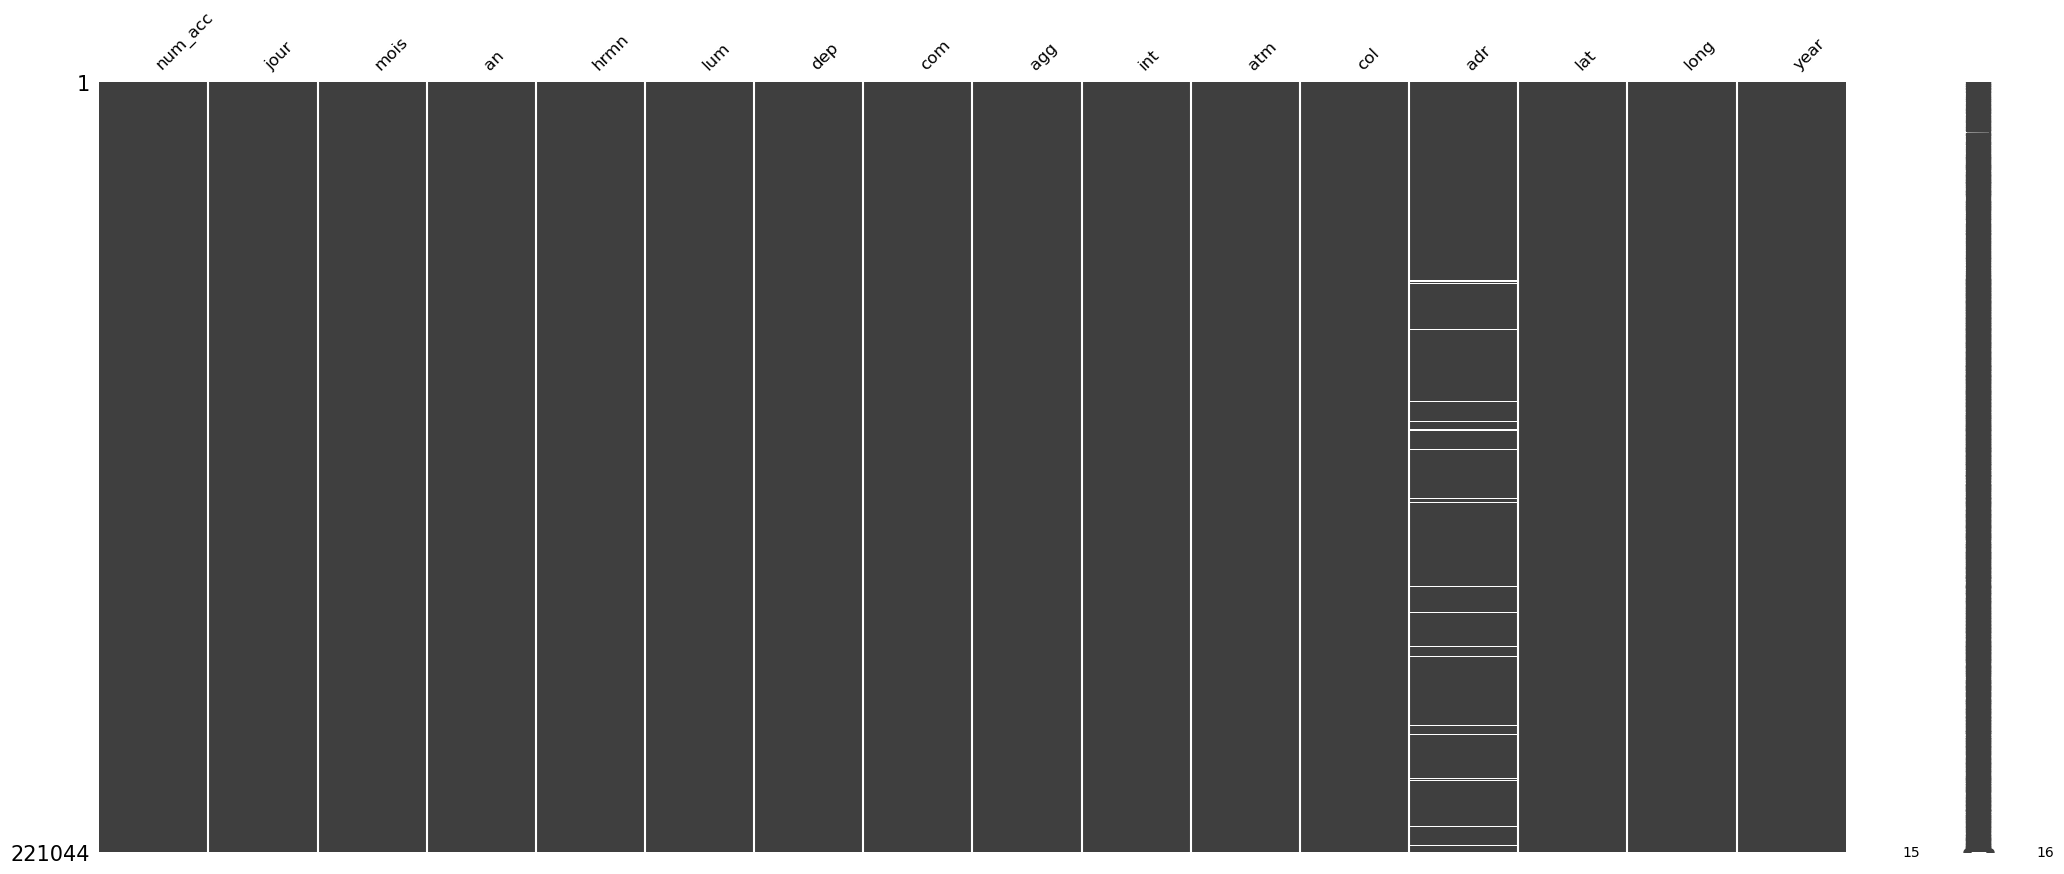

----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
df_lieux
Pourcentage de valeurs manquantes :


,Number of missing line,Percentage of missing line
lartpc,252728,99.92
v2,230883,91.28
voie,35290,13.95


Missingno :


<Figure size 1400x800 with 0 Axes>

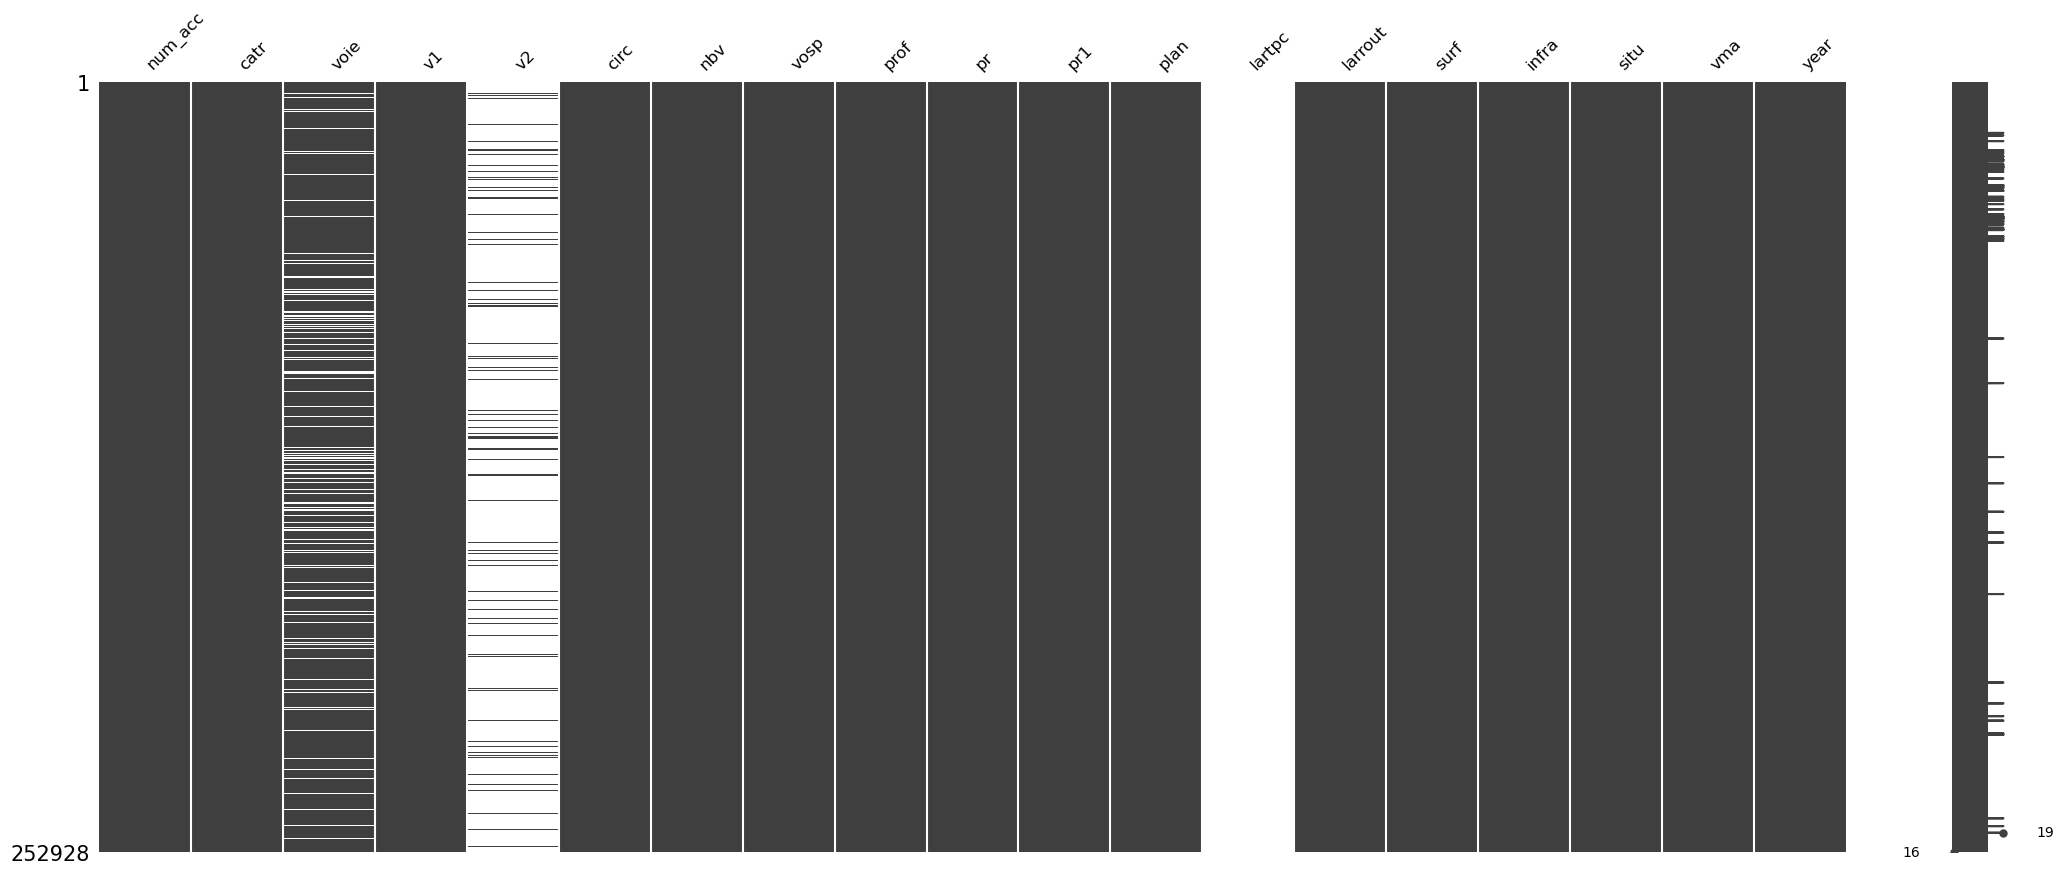

----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
df_usagers
Pourcentage de valeurs manquantes :


,Number of missing line,Percentage of missing line
an_nais,11118,2.19


Missingno :


<Figure size 1400x800 with 0 Axes>

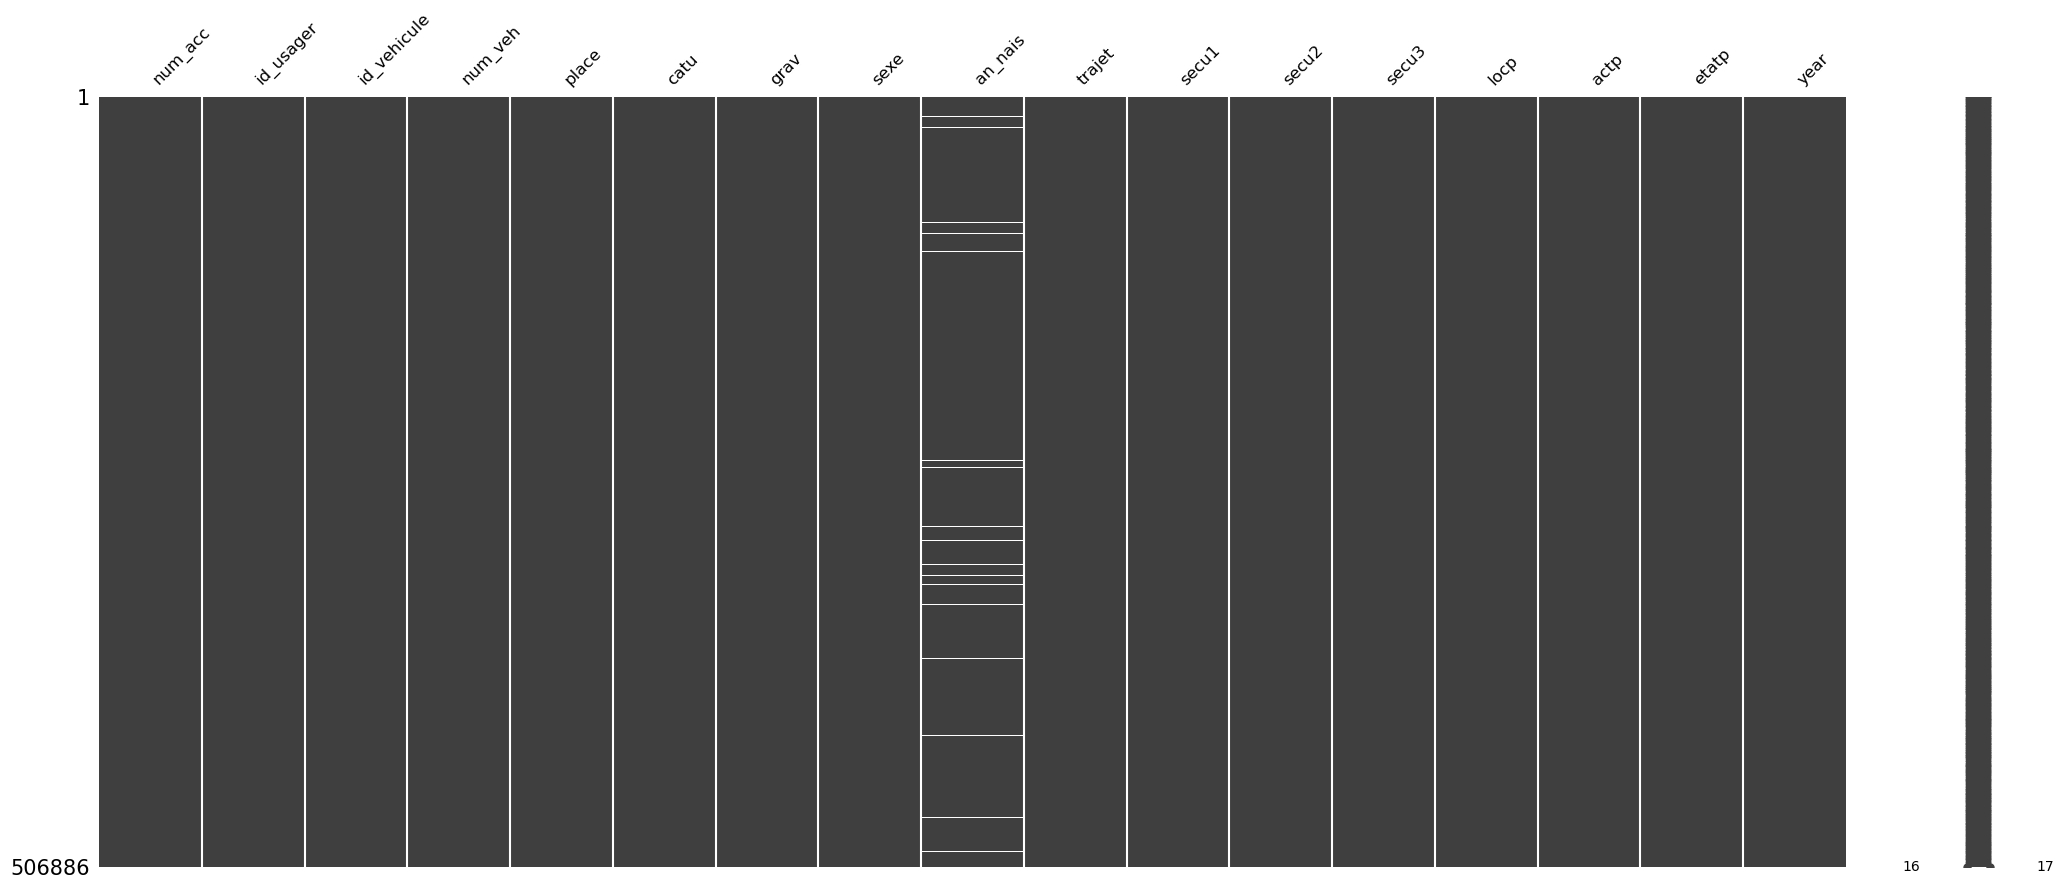

In [14]:
for name, df in concat_dfs.items() :
    data_missing = pd.DataFrame({
        "Number of missing line" : df.isnull().sum(),
        "Percentage of missing line" : (df.isnull().sum()/len(df)*100).round(2)
    }).sort_values("Percentage of missing line", ascending = False)
    print('-'*100)
    print('-'*100)
    print(name)
    print('Pourcentage de valeurs manquantes :')
    display(data_missing[data_missing["Number of missing line"]>0])
    print("Missingno :")
    plt.figure(figsize=(14, 8))
    msno.matrix(df, fontsize=12, sparkline=True)
    plt.show()

## 2.4 Visualisation de la répartition de la gravité, vérifier le déséquilibre de mes classes 

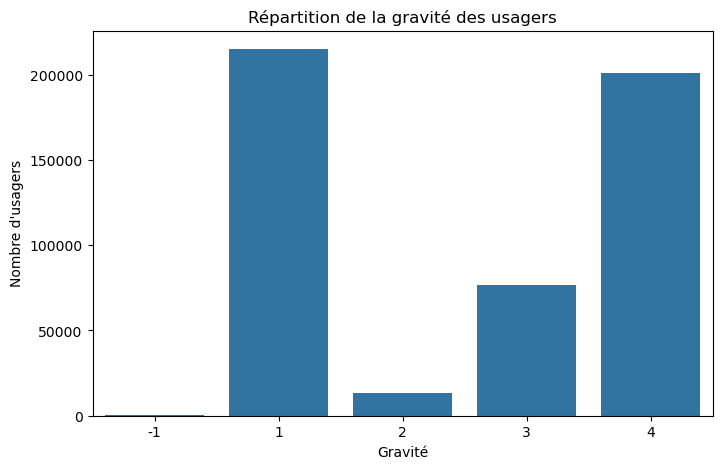

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_usagers,
    x='grav',
    order=sorted(df_usagers['grav'].dropna().unique())
)

plt.title("Répartition de la gravité des usagers")
plt.xlabel("Gravité")
plt.ylabel("Nombre d'usagers")
plt.show()


*1 – Indemne 2 – Tué 3 – Blessé hospitalisé 4 – Blessé léger*

***Ma variable cible est trop basse***

In [16]:
df_caract.head(1)

,num_acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long,year
0,202100000001,30,11,2021,07:32,2,30,30319,1,1,1,1,CD 981,"44,0389580000","4,3480220000",2021


## 2.5 Visualisation de l'importance de l'heure (donc de la luminosité) sur la gravité :

In [17]:
df_time = df_usagers.merge(
    df_caract[['num_acc', 'year', 'hrmn', 'lum']],
    on=['num_acc', 'year'],
    how='inner'
)
df_time['hrmn'] = df_time['hrmn'].replace(":", "", regex=True)
df_time['hrmn'] = df_time['hrmn'].astype(int)

df_time['heure'] = df_time['hrmn'] / 100

df_time.head(1)

,num_acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp,year,hrmn,lum,heure
0,202100000001,267 638,201 764,B01,1,1,3,1,2000.0,1,0,9,-1,0,0,-1,2021,732,2,7.32


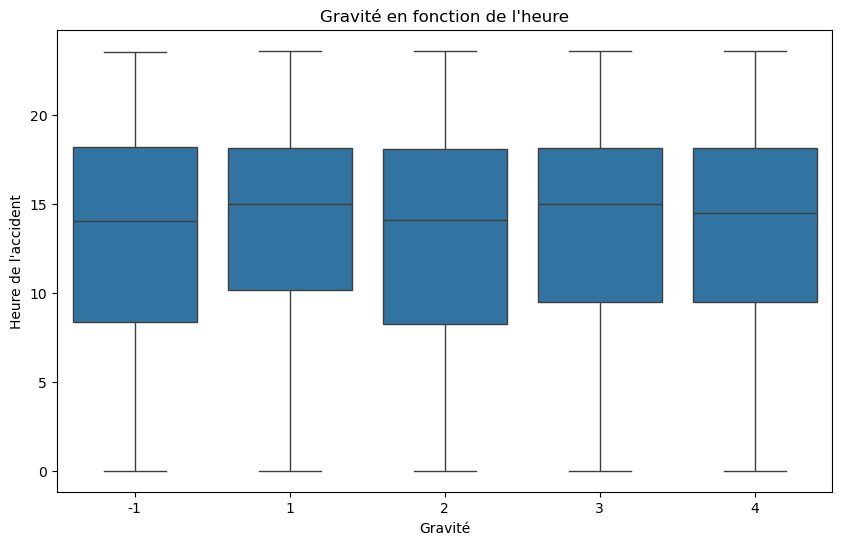

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_time,
    x='grav',
    y='heure'
)

plt.title("Gravité en fonction de l'heure")
plt.xlabel("Gravité")
plt.ylabel("Heure de l'accident")
plt.show()


*1 – Indemne 2 – Tué 3 – Blessé hospitalisé 4 – Blessé léger*

***L'heure n'a pas de réel impact sur la gravité***

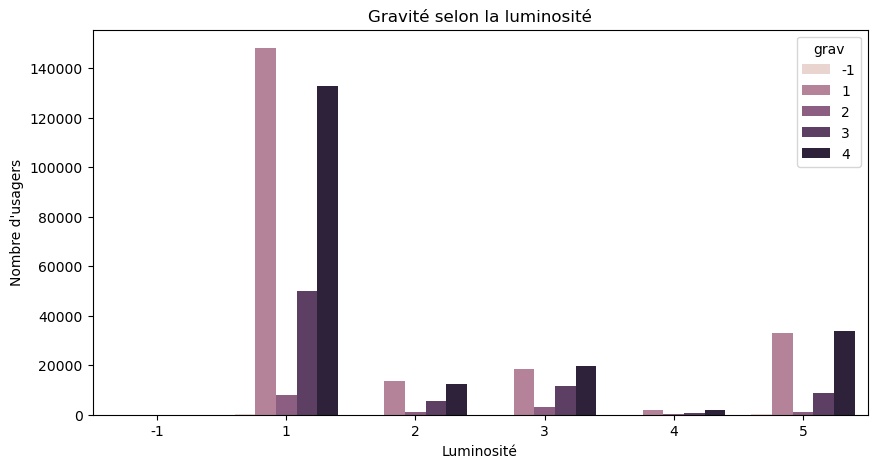

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_time,
    x='lum',
    hue='grav'
)

plt.title("Gravité selon la luminosité")
plt.xlabel("Luminosité")
plt.ylabel("Nombre d'usagers")
plt.show()


*1 – Indemne 2 – Tué 3 – Blessé hospitalisé 4 – Blessé léger*

*1 – Plein jour 2 – Crépuscule ou aube 3 – Nuit sans éclairage public 4 – Nuit avec éclairage public non allumé 5 – Nuit avec éclairage public allumé*

***La majorité des accident ont lieux en plein jour, suivi par la nuit sans éclairage public allumé.***

## 2.6 Vérification des coordonnées GPS :

*1 – Indemne 2 – Tué 3 – Blessé hospitalisé 4 – Blessé léger*

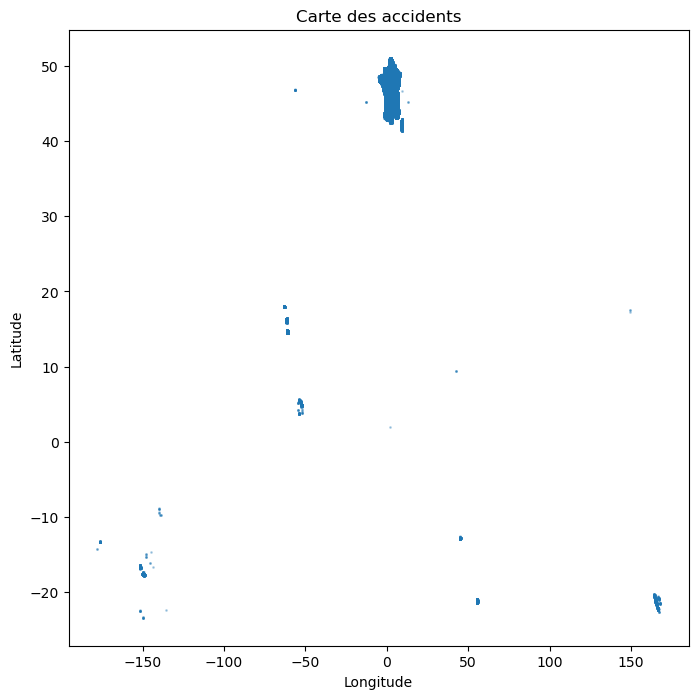

In [20]:
df_caract['long'] = df_caract['long'].replace(",", ".", regex=True).astype(float) # Modif du type colonnes 
df_caract['lat'] = df_caract['lat'].replace(",", ".", regex=True).astype(float)
plt.figure(figsize=(8,8))
plt.scatter(
    df_caract['long'],
    df_caract['lat'],
    s=1,
    alpha=0.3
)

plt.title("Carte des accidents")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


***Des points sont en dehors de la métropole, certains sont surement des dom-tom mais d'autre semblent faux ou aberrant, il faudra faire un cadrage pour garder que les coordonnées juste.***

## 2.7 Vérifier que les variables des usagers sont pertinents par rapport à la cible (gravité):

### 2.7.1 Trouver l'âge des usagers :

In [21]:
df_usagers['age'] = df_usagers['year'] - df_usagers['an_nais']


### 2.7.2 Visualisation de la gravité selon l'âge :

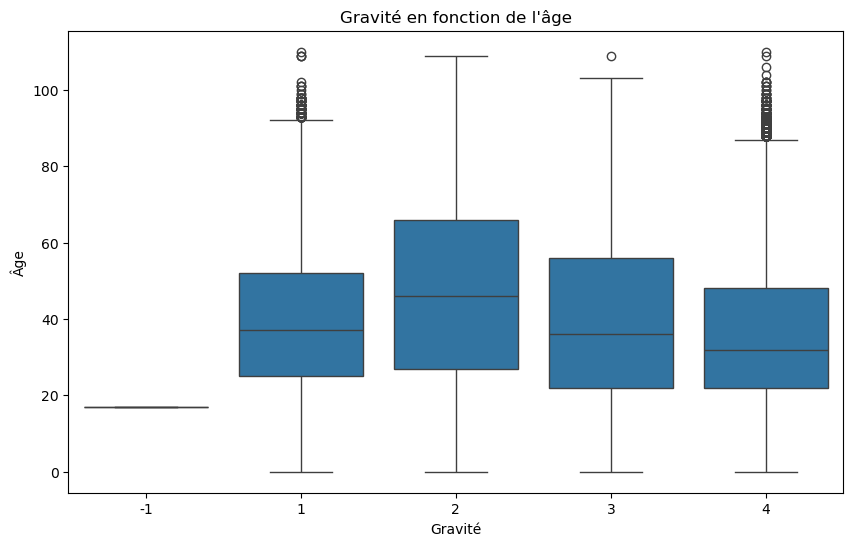

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_usagers,
    x='grav',
    y='age'
)

plt.title("Gravité en fonction de l'âge")
plt.xlabel("Gravité")
plt.ylabel("Âge")
plt.show()


*1 – Indemne 2 – Tué 3 – Blessé hospitalisé 4 – Blessé léger*

***L'âge médiant des prsonnes tué est autour de 45ans. La dispertion est très grande, en tous cas plus que pour les blessé léger ou hospitalisé. On peut en conclure que les décès touchent a peut près toutes les tranches d'âges mais touchent plus de personne plus âgée ue pour les autres blessé. Les blessé léger touchent une population bien plus jeune (age médian 30ans) mais étonnament aussi beaucoup de senior très agé (outlisers au delà de 100ans)***

### 2.7.3 Visualisation des personnes très agées :

In [23]:
filtered_df = df_usagers[df_usagers['age'] > 100]
display(filtered_df)

,num_acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp,year,age
985,202100000412,266 534,200 969,A01,10,3,2,2,1920.0,9,0,-1,-1,9,3,1,2021,101.0
4461,202100001879,262 924,198 434,B01,2,2,3,2,1912.0,0,1,-1,-1,-1,-1,-1,2021,109.0
12750,202100005487,254 280,191 985,A01,10,3,4,2,1920.0,0,0,-1,-1,3,3,2,2021,101.0
78950,202100034182,185 792,140 650,B01,1,1,1,1,1919.0,5,1,-1,-1,0,0,-1,2021,102.0
145617,202400007202,203 971 671,155 769 135,A01,1,1,4,1,1923.0,0,8,-1,-1,0,0,-1,2024,101.0
161889,202400014290,203 954 871,155 756 598,B01,1,1,1,2,1915.0,3,8,-1,-1,0,0,-1,2024,109.0
173431,202400019312,203 943 001,155 747 767,A01,10,3,2,1,1915.0,0,0,-1,-1,1,3,1,2024,109.0
195733,202400029100,203 920 003,155 730 534,B01,2,2,1,1,1914.0,4,1,-1,-1,-1,-1,-1,2024,110.0
216654,202400038046,203 898 482,155 714 709,A01,10,3,1,1,1923.0,0,0,-1,-1,4,3,2,2024,101.0
231064,202400044204,203 883 620,155 703 954,A01,5,2,4,1,1922.0,0,8,0,-1,-1,-1,-1,2024,102.0


## 2.8 Visualisation de la gravité selon le sexe :

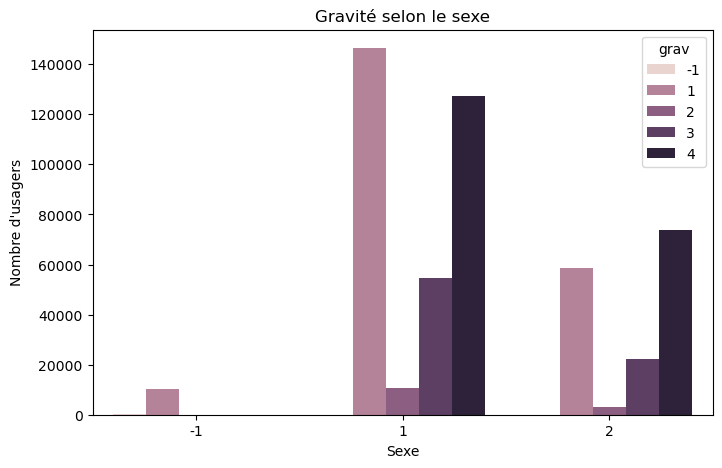

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_usagers,
    x='sexe',
    hue='grav'
)

plt.title("Gravité selon le sexe")
plt.xlabel("Sexe")
plt.ylabel("Nombre d'usagers")
plt.show()


*1 – Indemne 2 – Tué 3 – Blessé hospitalisé 4 – Blessé léger*

*1 – Masculin 2 – Féminin* 

## 2.9 Visualisation de la gravité selon la météo :

### 2.9.1 Création d'un dataset météo :

In [25]:
df_meteo = pd.merge(pd.merge(df_usagers, df_caract[['num_acc','atm']], on=['num_acc'], how='outer'),df_lieux[['num_acc','surf','catr']], on=['num_acc'], how='outer')

df_meteo.head(1)

,num_acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,...,secu2,secu3,locp,actp,etatp,year,age,atm,surf,catr
0,202100000001,267 638,201 764,B01,1,1,3,1,2000.0,1,...,9,-1,0,0,-1,2021,21.0,1,1,3


### 2.9.2 Gravité selon les condidtions atmosphériques :

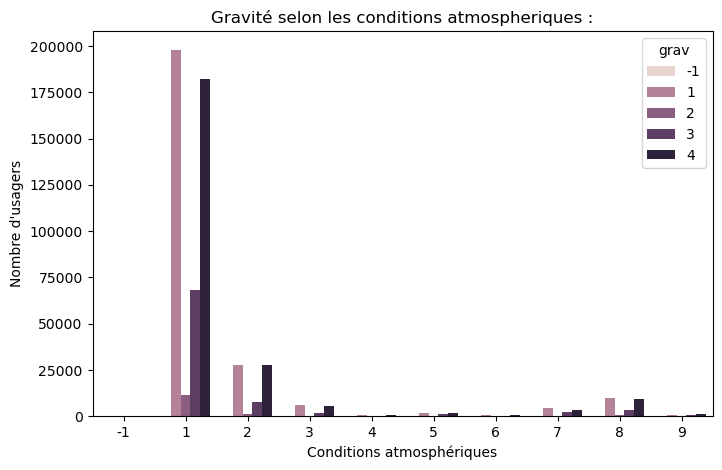

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_meteo,
    x='atm',
    hue='grav'
)

plt.title("Gravité selon les conditions atmospheriques :")
plt.xlabel("Conditions atmosphériques")
plt.ylabel("Nombre d'usagers")
plt.show()

*1 – Indemne 2 – Tué 3 – Blessé hospitalisé 4 – Blessé léger*

*-1 – Non renseigné
1 – Normale
2 – Pluie légère
3 – Pluie forte
4 – Neige - grêle
5 – Brouillard - fumée
6 – Vent fort - tempête
7 – Temps éblouissant
8 – Temps couvert
9 – Autre*

### 2.9.3 Gravité selon les conditions de chaussée :

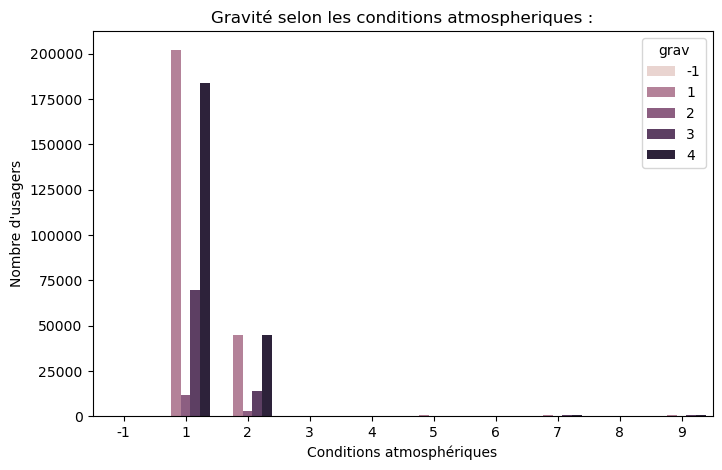

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_meteo,
    x='surf',
    hue='grav'
)

plt.title("Gravité selon les conditions atmospheriques :")
plt.xlabel("Conditions atmosphériques")
plt.ylabel("Nombre d'usagers")
plt.show()

*1 – Indemne 2 – Tué 3 – Blessé hospitalisé 4 – Blessé léger*

*1 – Normale
2 – Mouillée
3 – Flaques
4 – Inondée
5 – Enneigée
6 – Boue
7 – Verglacée
8 – Corps gras – huile
9 – Autre*

## 2.10 Visualisation gravité  selon le type de route :

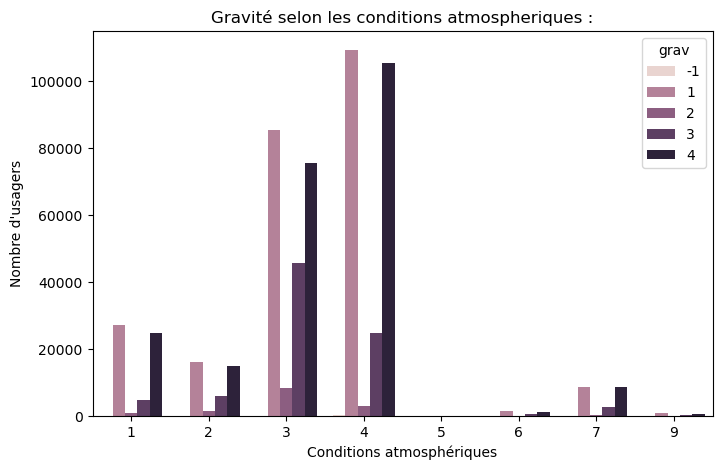

In [28]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_meteo,
    x='catr',
    hue='grav'
)

plt.title("Gravité selon les conditions atmospheriques :")
plt.xlabel("Conditions atmosphériques")
plt.ylabel("Nombre d'usagers")
plt.show()

*1 – Indemne 2 – Tué 3 – Blessé hospitalisé 4 – Blessé léger*

*1 – Autoroute
2 – Route nationale
3 – Route Départementale
4 – Voie Communales
5 – Hors réseau public
6 – Parc de stationnement ouvert à la circulation publique
7 – Routes de métropole urbaine
9 – autre*

## 2.10 Visualisation gravité  selon le type d'usager :

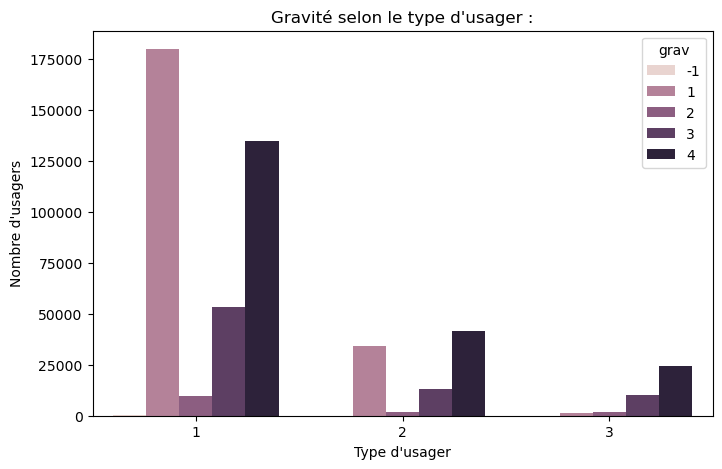

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_usagers,
    x='catu',
    hue='grav'
)

plt.title("Gravité selon le type d'usager :")
plt.xlabel("Type d'usager")
plt.ylabel("Nombre d'usagers")
plt.show()

*1 – Indemne 2 – Tué 3 – Blessé hospitalisé 4 – Blessé léger*

*1 – Conducteur
2 – Passager
3 – Piéton*

# 3. Nettoyage de données en fonction de mes visualisations précedente :

## 3.1 Selection des colonnes qui me semblent utiles par table :

In [30]:
df_caract_copy = df_caract
df_lieux_copy = df_lieux
df_usagers_copy = df_usagers

### 3.1.1 Table Caractéristiques :

In [31]:
print( "AVANT : ")
df_caract_copy.head(1)

AVANT : 


,num_acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long,year
0,202100000001,30,11,2021,07:32,2,30,30319,1,1,1,1,CD 981,44.038958,4.348022,2021


In [32]:
caract_cols = [
    'num_acc', 'year',
    'mois', 'jour', 'hrmn',
    'lum', 'atm',
    'lat', 'long'
]
df_caract_cl = df_caract_copy[caract_cols]
print("APRES")
df_caract_cl.head(1)

APRES


,num_acc,year,mois,jour,hrmn,lum,atm,lat,long
0,202100000001,2021,11,30,07:32,2,1,44.038958,4.348022


### 3.1.2 Table Lieux :

In [33]:
print( "AVANT : ")
df_lieux_copy.head(1)

AVANT : 


,num_acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma,year
0,202100000001,3,981,-1,NaN,2,2,0,1,(1),(1),1,NaN,-1,1,0,1,80,2021


In [34]:
lieux_cols = [
    'num_acc', 'year',
    'catr', 'circ', 'vosp',
    'prof', 'plan', 'surf'
]
df_lieux_cl = df_lieux_copy[lieux_cols]
print("APRES")
df_lieux_cl.head(1)

APRES


,num_acc,year,catr,circ,vosp,prof,plan,surf
0,202100000001,2021,3,2,0,1,1,1


### 3.1.3 Table Usagers :

In [35]:
print( "AVANT : ")
df_usagers_copy.head(1)

AVANT : 


,num_acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp,year,age
0,202100000001,267 638,201 764,B01,1,1,3,1,2000.0,1,0,9,-1,0,0,-1,2021,21.0


In [36]:
usagers_cols = [
    'num_acc', 'year',
    'grav', 'sexe', 'an_nais',
    'catu', 'trajet', 'id_vehicule'
]
df_usagers_cl = df_usagers_copy[usagers_cols]
print("APRES")
df_usagers_cl.head(1)

APRES


,num_acc,year,grav,sexe,an_nais,catu,trajet,id_vehicule
0,202100000001,2021,3,1,2000.0,1,1,201 764


## 3.2 Gestion des doublons :

In [37]:
df_caract_cl = df_caract_cl.drop_duplicates()
df_lieux_cl = df_lieux_cl.drop_duplicates()
df_usagers_cl = df_usagers_cl.drop_duplicates()

## 3.3 Gestion des types de colonnes :

### 3.3.1 Création d'un dict de mes nouveaux dataset pour boucler dessus facilement 

In [38]:
df_smaller = {"df_caract_cl" : df_caract_cl,
             "df_lieux_cl" : df_lieux_cl,
             "df_usagers_cl" : df_usagers_cl}

### 3.3.2 Affichage du type des colonnes :

In [39]:
for name, df in df_smaller.items() :
    print("-"*150)
    print(name," : ")
    print("-"*150)
    print("Shape : ", df.shape)
    display(df.head())
    print("Info : ")
    display(df.info())

------------------------------------------------------------------------------------------------------------------------------------------------------
df_caract_cl  : 
------------------------------------------------------------------------------------------------------------------------------------------------------
Shape :  (221044, 9)


,num_acc,year,mois,jour,hrmn,lum,atm,lat,long
0,202100000001,2021,11,30,07:32,2,1,44.038958,4.348022
1,202100000002,2021,9,25,14:20,1,1,49.242129,4.554546
2,202100000003,2021,7,15,07:55,1,7,46.921950,-0.964460
3,202100000004,2021,3,27,19:45,5,3,48.949363,2.519664
4,202100000005,2021,2,25,07:20,5,1,49.408380,1.145810


Info : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221044 entries, 0 to 221043
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   num_acc  221044 non-null  int64  
 1   year     221044 non-null  int64  
 2   mois     221044 non-null  int64  
 3   jour     221044 non-null  int64  
 4   hrmn     221044 non-null  object 
 5   lum      221044 non-null  int64  
 6   atm      221044 non-null  int64  
 7   lat      221044 non-null  float64
 8   long     221044 non-null  float64
dtypes: float64(2), int64(6), object(1)
memory usage: 15.2+ MB


None

------------------------------------------------------------------------------------------------------------------------------------------------------
df_lieux_cl  : 
------------------------------------------------------------------------------------------------------------------------------------------------------
Shape :  (244079, 8)


...

None

------------------------------------------------------------------------------------------------------------------------------------------------------
df_usagers_cl  : 
------------------------------------------------------------------------------------------------------------------------------------------------------
Shape :  (504250, 8)


,num_acc,year,grav,sexe,an_nais,catu,trajet,id_vehicule
0,202100000001,2021,3,1,2000.0,1,1,201 764
1,202100000001,2021,1,1,1978.0,1,1,201 765
2,202100000002,2021,4,1,1983.0,1,0,201 762
3,202100000002,2021,3,1,1993.0,1,0,201 763
4,202100000003,2021,1,1,1995.0,1,1,201 761


Info : 
<class 'pandas.core.frame.DataFrame'>
Index: 504250 entries, 0 to 506885
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   num_acc      504250 non-null  int64  
 1   year         504250 non-null  int64  
 2   grav         504250 non-null  int64  
 3   sexe         504250 non-null  int64  
 4   an_nais      493132 non-null  float64
 5   catu         504250 non-null  int64  
 6   trajet       504250 non-null  int64  
 7   id_vehicule  504250 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 34.6+ MB


None

### 3.3.3 Modification des types ( tout doit etre en int ou float)

**Il ne reste plus que la colonnes hrmn qui est en object :**

In [40]:
df_caract_cl['hrmn'] = df_caract_cl['hrmn'].replace(":", "", regex=True).astype(int)
df_caract_cl['hrmn'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 221044 entries, 0 to 221043
Series name: hrmn
Non-Null Count   Dtype
--------------   -----
221044 non-null  int64
dtypes: int64(1)
memory usage: 1.7 MB


### 3.3.4 Séparation de la colonne hrmn en heure et minute pour créer des colonnes temporelle

In [41]:
df_caract_cl['heure'] = df_caract_cl['hrmn'] // 100
df_caract_cl['minute'] = df_caract_cl['hrmn'] % 100 # Le modulo en python permet d'afficher le reste après une division
df_caract_cl.drop(columns='hrmn', inplace=True)


## 3.4 Gestion des coordonnée GPS, les recadrer juste autour de la France métropolitaine :

In [42]:
df_caract_cl = df_caract_cl[
    df_caract_cl['lat'].between(41, 52) &
    df_caract_cl['long'].between(-6, 10)
]


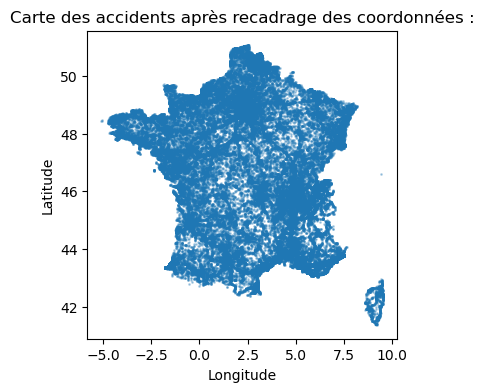

In [43]:
plt.figure(figsize=(4,4))
plt.scatter(
    df_caract_cl['long'],
    df_caract_cl['lat'],
    s=1,
    alpha=0.3
)

plt.title("Carte des accidents après recadrage des coordonnées :")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## 3.5 Création d'une colonne âge (plus pertinent)

In [44]:
df_usagers_cl['age'] = df_usagers_cl['year'] - df_usagers_cl['an_nais']
df_usagers.drop(columns='an_nais', inplace=True)

### 3.5.2 Gestion des outliers (plus de 100ans)

In [45]:
# Remplacer les outliers par les limites min/max acceptables.
p5 = df_usagers_cl['age'].quantile(0.05)
p95 = df_usagers_cl['age'].quantile(0.95)

df_usagers_cl['age'] = df_usagers_cl['age'].clip(lower=p5, upper=p95)


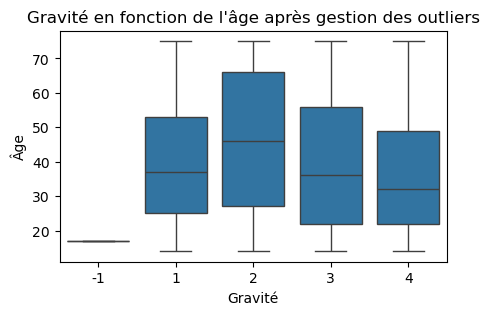

In [46]:
plt.figure(figsize=(5,3))
sns.boxplot(
    data=df_usagers_cl,
    x='grav',
    y='age'
)

plt.title("Gravité en fonction de l'âge après gestion des outliers")
plt.xlabel("Gravité")
plt.ylabel("Âge")
plt.show()

## 3.6 Gestion des colonnes contenant des "-1" (signifiant non renseigné) :

### 3.6.1 J'affiche si certaines colonnes contiennent des "-1" :

In [47]:
for name, df in df_smaller.items() :
    print("-"*100)
    print(name)
    for col in df.columns :
        value = df[col].value_counts(dropna=False)
        if -1 in value.index :
            print("-"*30)
            print("Colonne : ", col)
            print("-"*30)
            display(value)

----------------------------------------------------------------------------------------------------
df_caract_cl
------------------------------
Colonne :  lum
------------------------------


lum
 1    147819
 5     33754
 3     22622
 2     14610
 4      2235
-1         4
Name: count, dtype: int64

------------------------------
Colonne :  atm
------------------------------


atm
 1    174852
 2     24380
 8      8781
 3      5084
 7      3904
 5      1698
 9      1014
 4       723
 6       595
-1        13
Name: count, dtype: int64

------------------------------
Colonne :  long
------------------------------


...

grav
 1    213729
 4    199998
 3     76526
 2     13578
-1       419
Name: count, dtype: int64

------------------------------
Colonne :  sexe
------------------------------


sexe
 1    337323
 2    156295
-1     10632
Name: count, dtype: int64

------------------------------
Colonne :  trajet
------------------------------


trajet
 5    181817
 0    133136
 1     65650
 4     45278
 9     40624
 3     15502
-1     11265
 2     10978
Name: count, dtype: int64

### 3.6.2 Il y a pas mal de colonne avec des "-1" appart pour longitude ils représentent des NaN je vais doncles remplacer :

In [48]:
for name, df in df_smaller.items() :
    for col in df :
        if col == "long" :   # J'évite ma colonne longitude
            continue
        if (df[col] == -1).any() :
            df[col] = df[col].replace(-1, pd.NA)

In [49]:
for name, df in df_smaller.items() :
    print("-"*100)
    print(name)
    for col in df.columns :
        value = df[col].value_counts(dropna=False)
        if -1 in value.index :
            print("-"*30)
            print("Colonne : ", col)
            print("-"*30)
            display(value)

----------------------------------------------------------------------------------------------------
df_caract_cl
------------------------------
Colonne :  long
------------------------------


long
-149.549000    24
-149.560000    21
-150.202000    18
-149.568578    18
 5.400000      18
               ..
 1.447970       1
 5.338508       1
 0.361264       1
 1.835435       1
 6.128908       1
Name: count, Length: 203967, dtype: int64

----------------------------------------------------------------------------------------------------
df_lieux_cl
----------------------------------------------------------------------------------------------------
df_usagers_cl


**C'est bon tout est ok**

## 3.7 Gestion des valeurs manquantes :

### 3.7.1 Visualisation du pourcentage de valeurs manquante :

In [50]:
for name, df in df_smaller.items() :
    data_missing = pd.DataFrame({
        "Number of missing line" : df.isnull().sum(),
        "Percentage of missing line" : (df.isnull().sum()/len(df)*100).round(2)
    }).sort_values("Percentage of missing line", ascending = False)
    print('-'*100)
    print(name)
    print('Pourcentage de valeurs manquantes :')
    display(data_missing[data_missing["Number of missing line"]>0])

----------------------------------------------------------------------------------------------------
df_caract_cl
Pourcentage de valeurs manquantes :


,Number of missing line,Percentage of missing line
atm,13,0.01
lum,4,0.00


----------------------------------------------------------------------------------------------------
df_lieux_cl
Pourcentage de valeurs manquantes :


,Number of missing line,Percentage of missing line
circ,15382,6.30
vosp,8128,3.33
prof,280,0.11
surf,269,0.11
plan,220,0.09


----------------------------------------------------------------------------------------------------
df_usagers_cl
Pourcentage de valeurs manquantes :


,Number of missing line,Percentage of missing line
trajet,11265,2.23
age,11118,2.20
an_nais,11118,2.20
sexe,10632,2.11
grav,419,0.08


### 3.7.2 Supression des lignes qui contiennent moin de 5% de valeurs manquante (toute sauf une)

In [51]:
for name, df in df_smaller.items() :
    data_missing = df.isnull().sum()/len(df)*100
    cols_need_clean = data_missing[data_missing<= 5].index
    df.dropna(subset=cols_need_clean, inplace=True)
    

In [52]:
for name, df in df_smaller.items() :
    data_missing = pd.DataFrame({
        "Number of missing line" : df.isnull().sum(),
        "Percentage of missing line" : (df.isnull().sum()/len(df)*100).round(2)
    }).sort_values("Percentage of missing line", ascending = False)
    print('-'*100)
    print(name)
    print('Pourcentage de valeurs manquantes :')
    display(data_missing[data_missing["Number of missing line"]>0])

----------------------------------------------------------------------------------------------------
df_caract_cl
Pourcentage de valeurs manquantes :


,Number of missing line,Percentage of missing line


----------------------------------------------------------------------------------------------------
df_lieux_cl
Pourcentage de valeurs manquantes :


,Number of missing line,Percentage of missing line
circ,14850,6.29


----------------------------------------------------------------------------------------------------
df_usagers_cl
Pourcentage de valeurs manquantes :


,Number of missing line,Percentage of missing line


### 3.7.3 Gestion la colonne circ

In [53]:
df_lieux_cl['circ'].fillna(df_lieux_cl['circ'].mean())

/tmp/ipykernel_27269/3499045150.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_lieux_cl['circ'].fillna(df_lieux_cl['circ'].mean())


0         2.0
1         2.0
2         2.0
3         2.0
5         2.0
         ... 
252923    2.0
252924    2.0
252925    2.0
252926    2.0
252927    3.0
Name: circ, Length: 235906, dtype: float64

## 3.8 Merge final :

In [54]:
df_final = (
    df_usagers_cl
    .merge(df_caract_cl, on=['num_acc', 'year'], how='inner')
    .merge(df_lieux_cl, on=['num_acc', 'year'], how='inner')
)
df_final.head(2)

,num_acc,year,grav,sexe,an_nais,catu,trajet,id_vehicule,age,mois,...,lat,long,heure,minute,catr,circ,vosp,prof,plan,surf
0,202100000001,2021,3,1,2000.0,1,1,201 764,21.0,11,...,44.038958,4.348022,7,32,3,2,0,1,1,1
1,202100000001,2021,1,1,1978.0,1,1,201 765,43.0,11,...,44.038958,4.348022,7,32,3,2,0,1,1,1


In [55]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496256 entries, 0 to 496255
Data columns (total 23 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   num_acc      496256 non-null  int64  
 1   year         496256 non-null  int64  
 2   grav         496256 non-null  object 
 3   sexe         496256 non-null  object 
 4   an_nais      496256 non-null  float64
 5   catu         496256 non-null  int64  
 6   trajet       496256 non-null  object 
 7   id_vehicule  496256 non-null  object 
 8   age          496256 non-null  float64
 9   mois         496256 non-null  int64  
 10  jour         496256 non-null  int64  
 11  lum          496256 non-null  int64  
 12  atm          496256 non-null  int64  
 13  lat          496256 non-null  float64
 14  long         496256 non-null  float64
 15  heure        496256 non-null  int64  
 16  minute       496256 non-null  int64  
 17  catr         496256 non-null  int64  
 18  circ         466493 non-

In [56]:
df = df_final.copy()


# 4 Feature engineering :

#### **Ma target est toujours la gravité, je choisis de grouper par accident et de prendre la variable la plus élevé par accident. Je ne suis pas hyper convaincue par cette méthode car je pense qu'elle efface beaucoup de donnée et invisibilise potentiellement beaucoup d'accident. Par exmeple un lieux qui pourrait sous certaine condition avoir beaucoup d'accident léger. Exemple : un virage qui prenxs souvent le verglas et qui fait glisser les voiture pouvant impliquer plusieurs voiture mais sans faire d'accident de gros blessé ou de mort. Pour autant peut ont considérer ces accident comme non grave? De même un accident impliquant 30 blessé léger mais aucun mort ou blessé grave reste a mon sens grave.**

#### **Il faudrait peut etre faire une colonne qui m'afficherais la fréquence d'accident dans tel ou tel lieux je ne sais pas, enfain il pourrait y avoir d'autre colonne pertinent à rajouter pour amener de la finesse mais je choisis pour l'instant de ne pas compliquer la chose et je reviendrais dessus si j'ai le temps**

## 4.1 Création de colonnes :

### 4.1.1 Colonne pour la nuit

In [57]:
df['nuit'] = df['heure'].apply(lambda x: 1 if (x < 6 or x >= 21) else 0)


### 4.1.2 Colonne pour faire des tranches d'âge :

In [58]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 30, 45, 60, 75, 120],
    labels=['<18', '18-30', '30-45', '45-60', '60-75', '75+']
)

### 4.1.3 Je ne sais pas pourquoi mais  des colonnes sont retourné en objet

In [59]:
df['grav'] = df['grav'].astype(int)

### 4.1.4 Remettre grav dans l'ordre logique de gravité :

*La variable grav n’est pas ordonnée naturellement. Pour avoir une cible ordonnée :
0 = indemne (grav=1)1 = blessé léger (grav=4)2 = blessé hospitalisé (grav=3)3 = tué (grav=2)*

In [60]:
grav_map = {1: 0, 4: 1, 3: 2, 2: 3}

In [61]:
df["grav"] = df["grav"].map(grav_map)

## 4.2 Faire un group by par accident et donc gérer les doublons c'est à dire n'avoir qu'une ligne par accident :

In [62]:
df_accident_final = df.groupby(['num_acc', 'year']).agg(
    gravite_accident=('grav', 'max'),    # Je fait le choix de prendre la gravité maximale de l'accident 
    
    nb_usagers=('grav', 'count'),  # Je compte le nombre de passager (peut ête rajouter une colonne pour les autres gravité)
    
    age_moyen=('age', 'mean'),  # Faire une moyenne de tous les ages
    age_min=('age', 'min'),   # Mais montrer aussi l'âge minimal 
    age_max=('age', 'max'),   # Et l'age maximum pour ajouter de la finesse
    
    presence_enfant=('age', lambda x: int((x < 18).any())),   # Verifier qu'il y ai des mineurs 
    presence_senior=('age', lambda x: int((x >= 75).any())),  # Et vérifier si il y a des mineurs 
    presence_pieton=('catu', lambda x: int((x == 3).any())),   # Vérifier si il y a des piétons
    presence_passager=('catu', lambda x: int((x == 2).any())), # Vérifier si il y a des passagers


    nb_voiture=('id_vehicule', 'count'),
    
    
    nuit=('nuit', 'max'),    # Prendre le max de ma colonne nuit pr si jamais il y a plusieurs donnée (mais normalement non)
    
    mois=('mois', 'first'),    # Pour la suite je prends le first mais dans tous les cas c'est normalement les mêmes données 
    heure=('heure', 'first'),
    lum=('lum', 'first'),
    atm=('atm', 'first'),
    
    catr=('catr', 'first'),
    circ=('circ', 'first'),
    surf=('surf', 'first'),
    
    lat=('lat', 'first'),
    long=('long', 'first')
).reset_index()


In [63]:
df_accident_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207960 entries, 0 to 207959
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   num_acc            207960 non-null  int64  
 1   year               207960 non-null  int64  
 2   gravite_accident   207960 non-null  int64  
 3   nb_usagers         207960 non-null  int64  
 4   age_moyen          207960 non-null  float64
 5   age_min            207960 non-null  float64
 6   age_max            207960 non-null  float64
 7   presence_enfant    207960 non-null  int64  
 8   presence_senior    207960 non-null  int64  
 9   presence_pieton    207960 non-null  int64  
 10  presence_passager  207960 non-null  int64  
 11  nb_voiture         207960 non-null  int64  
 12  nuit               207960 non-null  int64  
 13  mois               207960 non-null  int64  
 14  heure              207960 non-null  int64  
 15  lum                207960 non-null  int64  
 16  at

In [64]:
df_accident_final.head()


,num_acc,year,gravite_accident,nb_usagers,age_moyen,age_min,age_max,presence_enfant,presence_senior,presence_pieton,...,nuit,mois,heure,lum,atm,catr,circ,surf,lat,long
0,202100000001,2021,2,2,32.0,21.0,43.0,0,0,0,...,0,11,7,2,1,3,2,1,44.038958,4.348022
1,202100000002,2021,2,2,33.0,28.0,38.0,0,0,0,...,0,9,14,1,1,3,2,1,49.242129,4.554546
2,202100000003,2021,2,2,44.0,26.0,62.0,0,0,1,...,0,7,7,1,7,4,2,1,46.921950,-0.964460
3,202100000004,2021,3,1,14.0,14.0,14.0,1,0,0,...,0,3,19,5,3,3,2,1,48.949363,2.519664
4,202100000006,2021,1,2,29.5,14.0,45.0,1,0,0,...,0,11,11,1,1,4,2,1,47.614239,7.234336


In [65]:
df_accident_final['surf'] = df_accident_final['surf'].astype(int)

In [66]:
df_accident_final['surf'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 207960 entries, 0 to 207959
Series name: surf
Non-Null Count   Dtype
--------------   -----
207960 non-null  int64
dtypes: int64(1)
memory usage: 1.6 MB


In [67]:
df_accident_final.to_csv("df_accident_final.csv", index=False)

## 4.3 Chois de target binaire ou multi class 

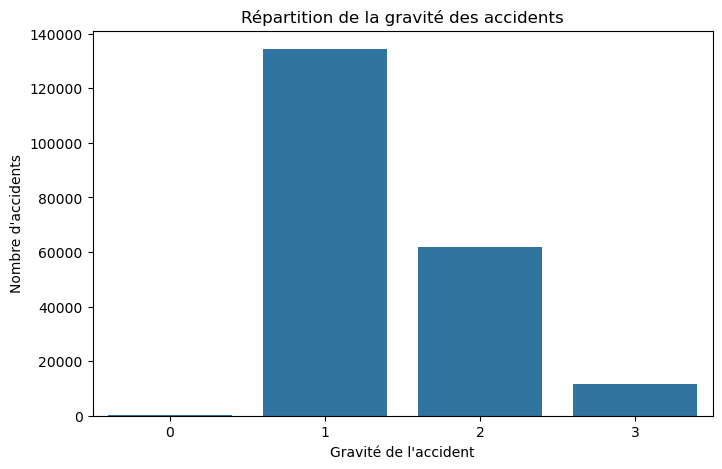

In [68]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_accident_final,
    x='gravite_accident',
    order=sorted(df_accident_final['gravite_accident'].unique())
)

plt.title("Répartition de la gravité des accidents")
plt.xlabel("Gravité de l'accident")
plt.ylabel("Nombre d'accidents")
plt.show()


***Il n'y a pas d'indemne étant donné que les donnée du dataset sont remplie que s'il y a eu au moin un blessé, comme je fait une aggregation.***

***Il y a très peut de gravité 3 (mort) le dataset est donc très désiquilibré je ne peux pas faire de la multiclass, je vais faire du binaire avec grave comme >= à 2***

## 4.4 Vérification de la pertinence de mes features :

### 4.4.1 Feature nuit :

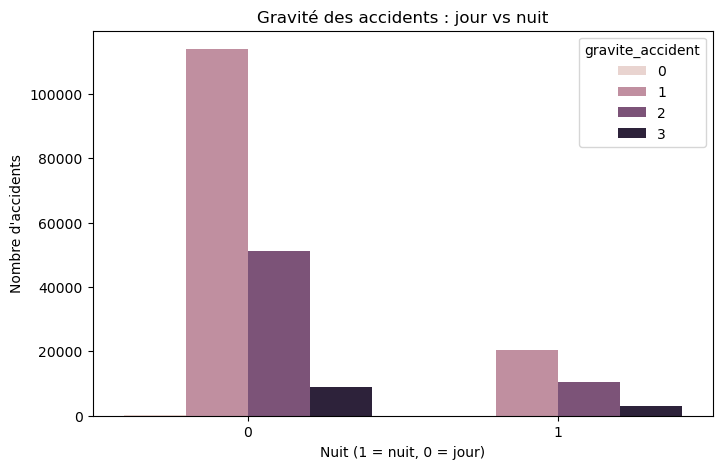

In [69]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_accident_final,
    x='nuit',
    hue='gravite_accident'
)

plt.title("Gravité des accidents : jour vs nuit")
plt.xlabel("Nuit (1 = nuit, 0 = jour)")
plt.ylabel("Nombre d'accidents")
plt.show()


*0 = indemne / 1 = blessé léger / 2 = blessé hospitalisé / 3 = tué*

***La nuit il y a plus de chance qu'un accident grave arrive par rapport à des blessé léger***

### 4.4.2 Feature luminosité :

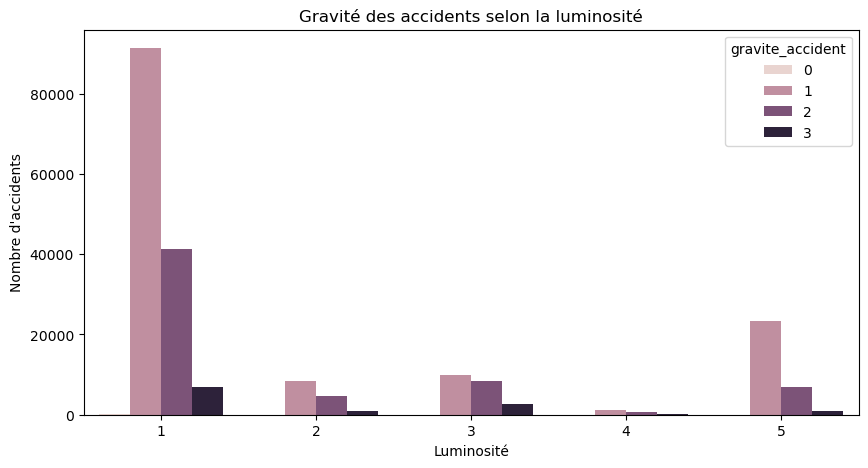

In [70]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_accident_final,
    x='lum',
    hue='gravite_accident'
)

plt.title("Gravité des accidents selon la luminosité")
plt.xlabel("Luminosité")
plt.ylabel("Nombre d'accidents")
plt.show()


*1 – Plein jour
2 – Crépuscule ou aube
3 – Nuit sans éclairage public
4 – Nuit avec éclairage public non allumé
5 – Nuit avec éclairage public allumé*

***Certaine luminosité sont associé a des accident plus ou moin grave***

### 4.4.3 Feature type de route :

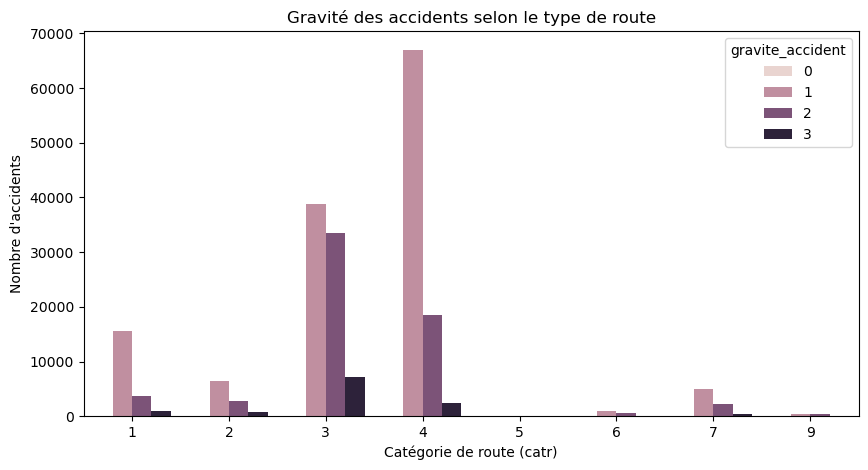

In [71]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_accident_final,
    x='catr',
    hue='gravite_accident'
)

plt.title("Gravité des accidents selon le type de route")
plt.xlabel("Catégorie de route (catr)")
plt.ylabel("Nombre d'accidents")
plt.show()


*1 – Autoroute
2 – Route nationale
3 – Route Départementale
4 – Voie Communales
5 – Hors réseau public
6 – Parc de stationnement ouvert à la circulation publique
7 – Routes de métropole urbaine
9 – autre*

***Les accident mortel ont lieux le plus souvent sur des route départementale***

In [72]:
### Feature age moyen / presence enfant / presence piéton :

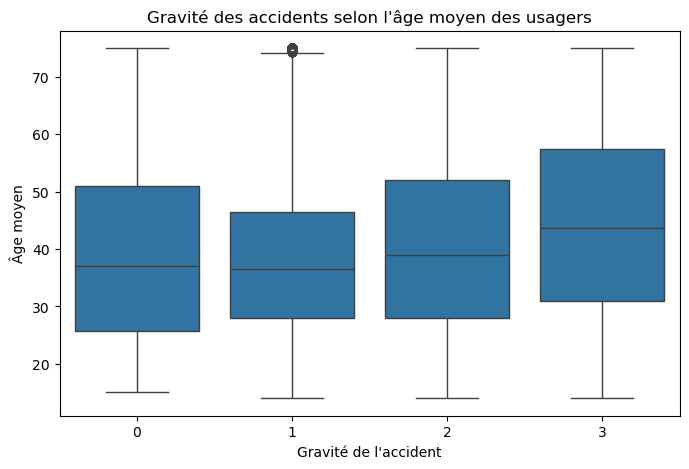

In [73]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_accident_final,
    x='gravite_accident',
    y='age_moyen'
)

plt.title("Gravité des accidents selon l'âge moyen des usagers")
plt.xlabel("Gravité de l'accident")
plt.ylabel("Âge moyen")
plt.show()


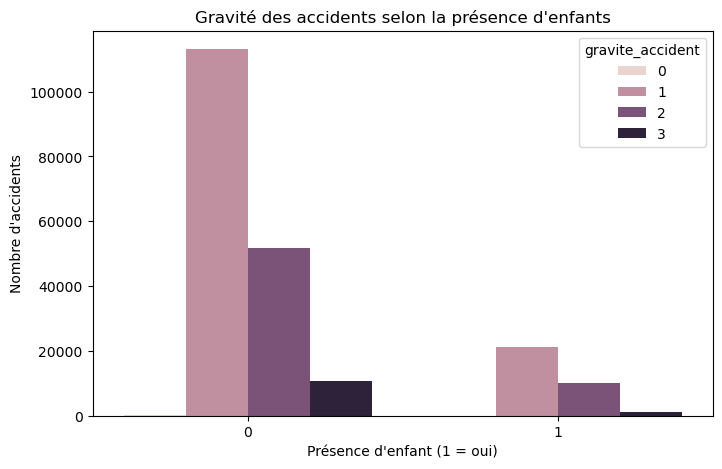

In [74]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_accident_final,
    x='presence_enfant',
    hue='gravite_accident'
)

plt.title("Gravité des accidents selon la présence d'enfants")
plt.xlabel("Présence d'enfant (1 = oui)")
plt.ylabel("Nombre d'accidents")
plt.show()


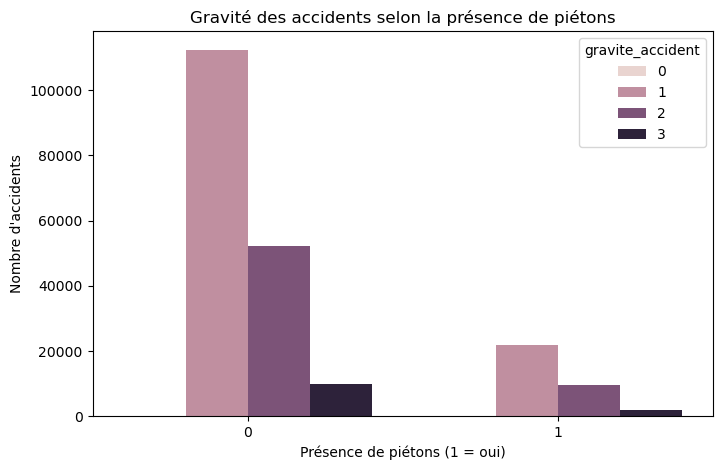

In [75]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_accident_final,
    x='presence_pieton',
    hue='gravite_accident'
)

plt.title("Gravité des accidents selon la présence de piétons")
plt.xlabel("Présence de piétons (1 = oui)")
plt.ylabel("Nombre d'accidents")
plt.show()

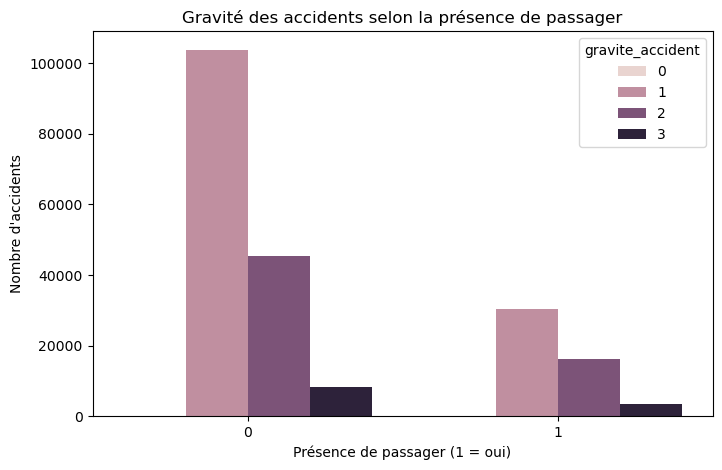

In [76]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_accident_final,
    x='presence_passager',
    hue='gravite_accident'
)

plt.title("Gravité des accidents selon la présence de passager")
plt.xlabel("Présence de passager (1 = oui)")
plt.ylabel("Nombre d'accidents")
plt.show()

***On remarque que chaqune de ces présence ont moin souvent de blessure légère et une plus grosse propartion comparativement de mort ou blessure grave, surtout concernant la présence de passager***

## 4.5 Cartographie :

#### **4.5.1 Cartographie des accident mortel VS des accident avec blessure légère :**

In [77]:
df_mortels = df_accident_final[df_accident_final['gravite_accident'] == 3]


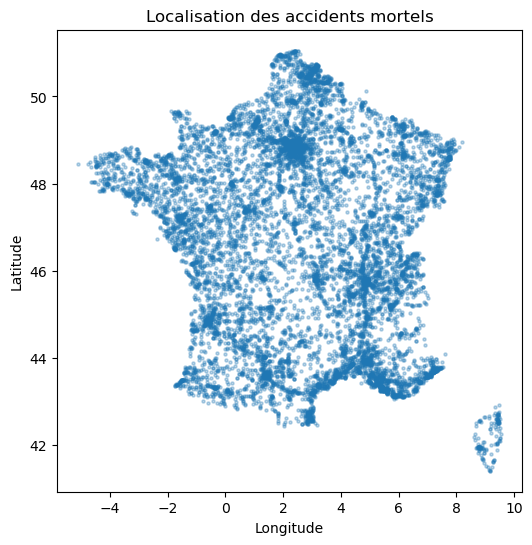

In [78]:
plt.figure(figsize=(6,6))
plt.scatter(
    df_mortels['long'],
    df_mortels['lat'],
    s=5,
    alpha=0.3
)

plt.title("Localisation des accidents mortels")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()



In [79]:
df_blessure_legere = df_accident_final[df_accident_final['gravite_accident'] == 1]


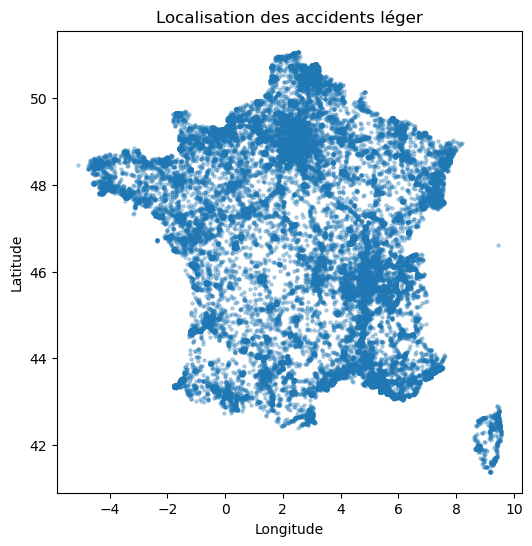

In [80]:
plt.figure(figsize=(6,6))
plt.scatter(
    df_blessure_legere['long'],
    df_blessure_legere['lat'],
    s=5,
    alpha=0.3
)

plt.title("Localisation des accidents léger")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()



*On voit les accident mortel se déssiner sur les **grandes agglomération** (Paris, Lille, Lyon, Bordeaux, Strasbourg, Toulouse, Nante) et le **littoral méditérannéen** ainsi que sur les **grands axe routiers** (autoroute **A7**(Marseille-Lyon), **A6**(Lyon-Dijon), **A61**(Narbonne - Toulouse), **A62**(Toulouse - Bordeaux) et même **A71**(Clermont-Ferrand - Orléans) et **A11**(Paris - Le Mans)*

*A contrario les accident avec uniquement des blessure légère sont beacoup plus diffu sur la France*

In [81]:
df_mortels_hiver = df_accident_final[(df_accident_final['gravite_accident'] == 3) & (df_accident_final['mois'].isin([12, 1, 2])) ]

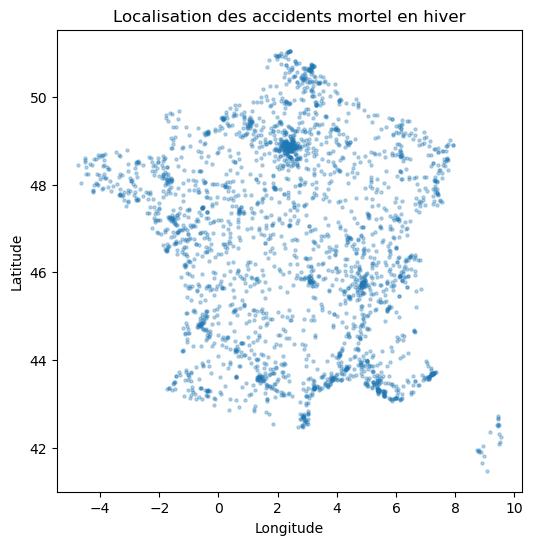

In [82]:
plt.figure(figsize=(6,6))
plt.scatter(
    df_mortels_hiver['long'],
    df_mortels_hiver['lat'],
    s=5,
    alpha=0.3
)

plt.title("Localisation des accidents mortel en hiver")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [83]:
df_mortels_ete = df_accident_final[(df_accident_final['gravite_accident'] == 3) & (df_accident_final['mois'].isin([6, 7, 8])) ]

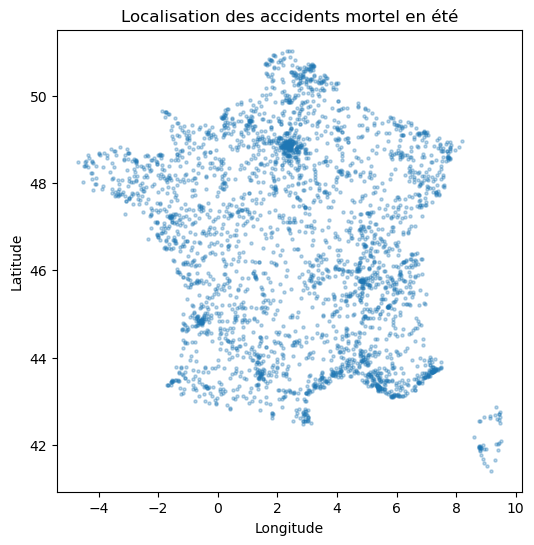

In [84]:
plt.figure(figsize=(6,6))
plt.scatter(
    df_mortels_ete['long'],
    df_mortels_ete['lat'],
    s=5,
    alpha=0.3
)

plt.title("Localisation des accidents mortel en été")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


**On remarque que le littoral méditerranéen reste accidentogène peut importe la saison mais tout de même un peu plus en été**

***L’analyse exploratoire montre un fort déséquilibre de la gravité des accidents, justifiant un passage en classification binaire. Les variables temporelles (nuit, luminosité), infrastructurelles (type de route) et issues des usagers (âge moyen, présence d’enfants) présentent un lien clair avec la gravité. La cartographie met en évidence des zones à risque, confirmant la cohérence géographique des données.***

# 5. Modélisation

In [85]:
df_ml = df_accident_final.copy()


## 5.1 Création d'une target binaire :

In [86]:
df_ml['target'] = df_ml['gravite_accident'].apply(lambda x: 1 if x >= 2 else 0)

In [87]:
df_ml['target'].value_counts(normalize=True)


target
0    0.646552
1    0.353448
Name: proportion, dtype: float64

**On voit une proportion déséquilibrée mais quand même améliorée**

## 5.2 Création des features :

In [88]:
features = [
    'nb_usagers',
    'age_moyen',
    'age_min',
    'age_max',
    'presence_enfant',
    'presence_senior',
    'presence_pieton',
    'presence_passager',
    'nb_voiture',
    'nuit',
    'heure',
    'lum',
    'atm',
    'catr',
    'surf'
]
# Pas de données GPS brut
X = df_ml[features]
y = df_ml['target']


## 5.3 Encodage des variable catégorielles :

### 5.3.1 Création d'une liste avec les feature catégoriel et une liste avec le reste

In [89]:
categorical_features = ['catr', 'surf']
numerical_features = [col for col in features if col not in categorical_features]


### 5.3.2 Utilisation du columntransformer sklearn  très pratique et réutilisable dans le pipeline :

In [90]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)


## 5.4 Séparation des données :

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## 5.5 Modèle 1 : Modèle simple pour me servir de référence : Une régression logisitique :

### 5.5.1 Utilisation d'un pipeline sklearn pour enchainer les étapes:

In [92]:
logreg = Pipeline(steps=[
    ('preprocessor', preprocessor),        # Mon column transformer
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'            # Utlisation de class_weight pour essayer d'équilibrer ma target
    ))
])


### 5.5.2 Entrainement et metrics :

In [93]:
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.77      0.66      0.71     26891
           1       0.50      0.64      0.56     14701

    accuracy                           0.65     41592
   macro avg       0.63      0.65      0.63     41592
weighted avg       0.67      0.65      0.66     41592



/home/sam/anaconda3/envs/tp_ml_route/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**La régression logistique a une précision plutot bien pour la classe 0 (0.77) et plus faible pour la classe 1 (0.50), avec un recall un peu plus élevé pour la classe 1 (accident grave)(0.64), ce qui signifie que le modèle trouve environ 64 % des vrai accidents graves. L’accuracy globale est de 0.65, c'est moyen, le modèle est ok entre la détection des deux classes.**

## 5.6 Modèle 2 : Un random forest qui devrait mieux gérer le bruit :

### 5.6.1 Utilisation d'un pipeline sklearn pour enchainer les étapes:

In [94]:
ranfore = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])


### 5.6.2 Entrainement et metrics :

In [95]:
ranfore.fit(X_train, y_train)

y_pred_rf = ranfore.predict(X_test)

print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.78      0.68      0.73     26891
           1       0.52      0.64      0.58     14701

    accuracy                           0.67     41592
   macro avg       0.65      0.66      0.65     41592
weighted avg       0.69      0.67      0.67     41592



*Le random forest est globalement un peu meilleur, avec une **précision** de **0.78** pour les blessures légères et **0.52** pour les accidents graves. Le **recall** des blessures légère est de **0.68** et celui des accidents graves est de **0.64** donc le modèle détecte un peu mieux les deux types d’accidents et son **accuracy** est aussi meilleure : **0.67**.*

## 5.7 Modèle 3 : catboost, nouveau modèle jamais testé, apparement il gère mieux le déséquilibre et les var catégorielle

### 5.7.1 Avec catboost il faut d'abord identifier les variable catégorielle :

In [96]:
# Xboost n'utlise pas les noms des colonnes, il a besoins de leur positionnement.
# On prends donc le poistionnement de leur index, ici 13 et 14 comme vu dans le print.

categorical_features_cat = ['catr', 'surf','lum','atm']

cat_features = [X.columns.get_loc(col) for col in categorical_features_cat]
print (cat_features)

[13, 14, 11, 12]


In [97]:
# On fait une copie de mon df avec mes features X car on va lui appliquer cat_features et non plus processor

X_cat = X.copy()

### 5.7.2 On doit donc refaire le train test split avec le nouveau X_cat

In [98]:
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### 5.7.3 On défini ensuite les paramètre de notre modèle, plus de pipeline sklearn donc on doit le définir avant l'entrainement:

In [99]:
cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function='Logloss',
    class_weights=[1, 5],
    verbose=0
)


### 5.7.4 Entrainement et metrics :

In [100]:
cat_model.fit(
    X_train_cat,
    y_train_cat,
    cat_features=cat_features
)

y_pred_cat = cat_model.predict(X_test_cat)

print(classification_report(y_test_cat, y_pred_cat))


              precision    recall  f1-score   support

           0       0.86      0.20      0.32     26891
           1       0.39      0.94      0.55     14701

    accuracy                           0.46     41592
   macro avg       0.63      0.57      0.44     41592
weighted avg       0.70      0.46      0.40     41592



*Ici c'est un peu la cata... CatBoost montre un recall très élevé pour les accidents graves (0.94), c'est bien en soit, il identifie presque tous les accidents graves, par contre mais il a beacoup de mal avec les blessures légères (rappel de 0.20). Donc, il cré beaucoup de fausses alertes sur la classe grave et une accuracy globale faible (0.46). Ce modèle est donc très sensible aux accidents graves mais au prix d’une mauvaise détection des blessures légères.*

## 6. Choix du modèle random forest - Anlayse des features les plus importantes :

## 6.1 Récupération du processor et du pipeline de mon random forest :

In [101]:
preprocessor = ranfore.named_steps['preprocessor']
classifier = ranfore.named_steps['classifier']

## 6.2  Obtention des noms des features y compris celle sur lequels on a appliqué le onehot encoding

In [102]:
num_features = numerical_features

cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features = list(num_features) + list(cat_features)
print(all_features)

['nb_usagers', 'age_moyen', 'age_min', 'age_max', 'presence_enfant', 'presence_senior', 'presence_pieton', 'presence_passager', 'nb_voiture', 'nuit', 'heure', 'lum', 'atm', 'catr_1', 'catr_2', 'catr_3', 'catr_4', 'catr_5', 'catr_6', 'catr_7', 'catr_9', 'surf_1', 'surf_2', 'surf_3', 'surf_4', 'surf_5', 'surf_6', 'surf_7', 'surf_8', 'surf_9']


## 6.3 On regarde l'importance grace a la méthode feature importance de sklearn :

In [103]:
importances = classifier.feature_importances_

## 6.4 On affiche tous ca sous forme de dataframe et de barplot:

In [104]:
feature_importances = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importances.head(20) 

,feature,importance
15,catr_3,0.260392
16,catr_4,0.184589
1,age_moyen,0.081071
2,age_min,0.065894
11,lum,0.063512
3,age_max,0.054740
13,catr_1,0.045377
8,nb_voiture,0.036693
0,nb_usagers,0.035864
10,heure,0.031932


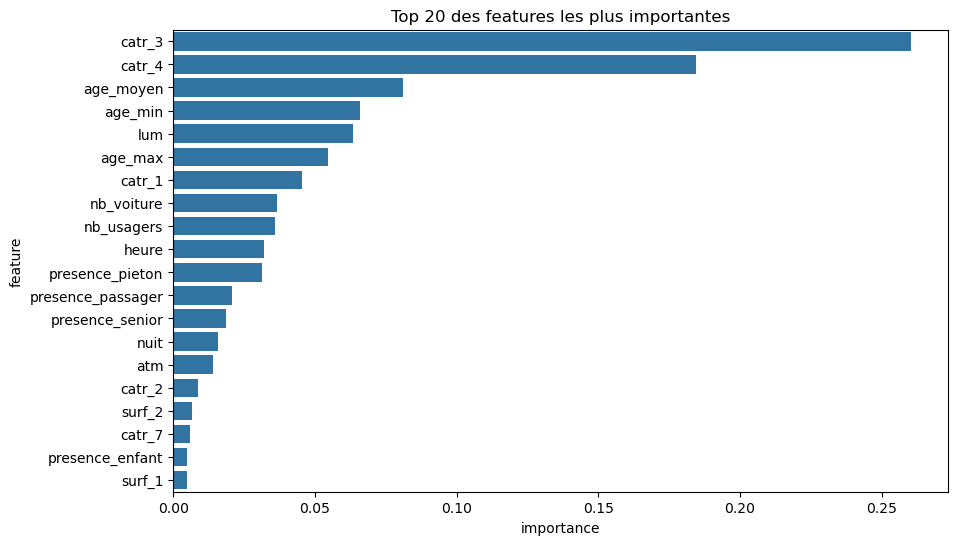

In [105]:
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importances.head(20))
plt.title("Top 20 des features les plus importantes")
plt.show()


### 6.5 Récupération du modèle :

In [106]:
joblib.dump(ranfore, "model_accidents_.pkl")

['model_accidents_.pkl']